In [2]:
import importlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import src.data.loader as loader
import src.indicators.ema as ema
import src.strategies.ema_crossover as ema_crossover
import src.backtest as backtest
import src.reporting.notebook_views as views
    

# Investigating Half-Life Impact on Returns
We use a simple cross-over strategy with EMAs (Exponential Moving Averages) at
two different time-scales. 

## Initial Data Load

Number of data-points: 753


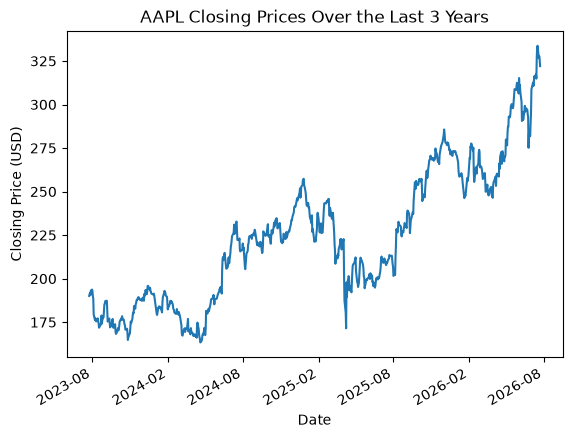

In [3]:
aapl_df = loader.get_prices(ticker="AAPL", period="3y")
print(f"Number of data-points: {len(aapl_df)}")
fig = plt.plot(aapl_df.index, aapl_df['Close'])
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.gcf().autofmt_xdate()
plt.title("AAPL Closing Prices Over the Last 3 Years")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.show()

## Computing and Plotting Some EMAs

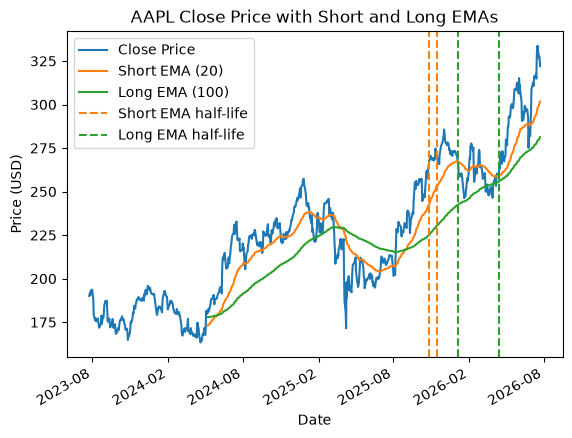

In [4]:
short_ema = ema.get_ema_series(aapl_df, period=200, halflife=20)
long_ema = ema.get_ema_series(aapl_df, period=200, halflife=100)

l1 = plt.plot(aapl_df.index, aapl_df['Close'], color="tab:blue", label='Close Price')
l2 = plt.plot(aapl_df.index, short_ema, color="tab:orange", label='Short EMA (20)')
l3 = plt.plot(aapl_df.index, long_ema, color="tab:green", label='Long EMA (100)')
plt.axvline(x=aapl_df.index[-1] - pd.DateOffset(days=250), color='tab:orange', label='Short EMA half-life', linestyle='--')
plt.axvline(x=aapl_df.index[-1] - pd.DateOffset(days=270), color='tab:orange', linestyle='--')
plt.axvline(x=aapl_df.index[-1] - pd.DateOffset(days=100), color='tab:green', label='Long EMA half-life', linestyle='--')
plt.axvline(x=aapl_df.index[-1] - pd.DateOffset(days=200), color='tab:green', linestyle='--')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.gcf().autofmt_xdate()

plt.title("AAPL Close Price with Short and Long EMAs")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

### Computing the Positions and Returns

We use the canonical half-lives and compare the results to a simple buy-and-hold 
benchmark. The benchmark has better returns, but higher annualized volatility,
resulting in lower Sharpe ratio.

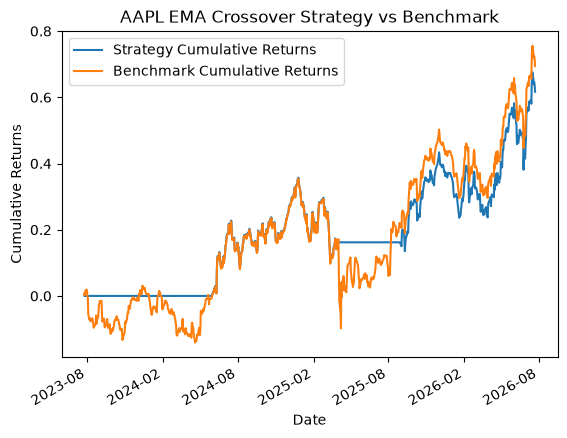

In [5]:
positions = ema_crossover.get_ema_crossover_positions(short_ema, long_ema, long_only=True)
metrics, strategy_cumulative_returns, benchmark_cumulative_returns = backtest.compute_metrics_and_returns_from_positions_and_prices(positions, aapl_df)

views.render_metrics_grouped(metrics)
views.plot_cumulative_returns(strategy_cumulative_returns, benchmark_cumulative_returns, title="AAPL EMA Crossover Strategy vs Benchmark")

### Using a Long-Short strategy instead of Long-Only

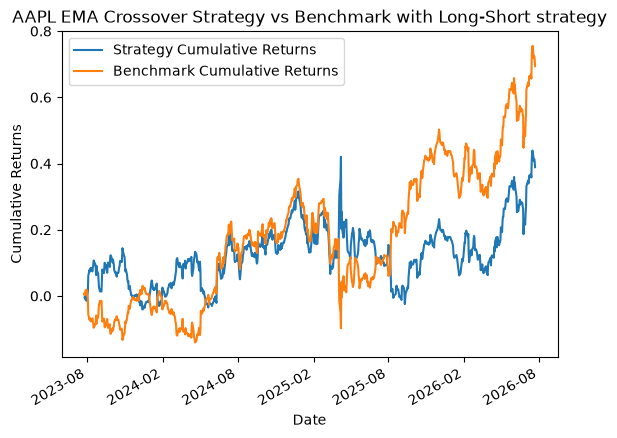

In [6]:
positions = ema_crossover.get_ema_crossover_positions(short_ema, long_ema, long_only=False)
metrics, strategy_cumulative_returns, benchmark_cumulative_returns = backtest.compute_metrics_and_returns_from_positions_and_prices(positions, aapl_df)

views.render_metrics_grouped(metrics)
views.plot_cumulative_returns(strategy_cumulative_returns, benchmark_cumulative_returns, title="AAPL EMA Crossover Strategy vs Benchmark with Long-Short strategy")

The strategy gives a bearish signal throughout the middle of 2025, and this 
extends into the sudden upturn around October. This heavily punishes the simple 
long-short strategy, and is largely responsible for its underperforming both the
benchmark and the long-only strategy.

## Parameter Sweeps

We conduct parameter sweeps to observe the effect of varying both the short and
long timescales.

### Long time-scale

We sweep from a half-life of 200 business days to 30. 

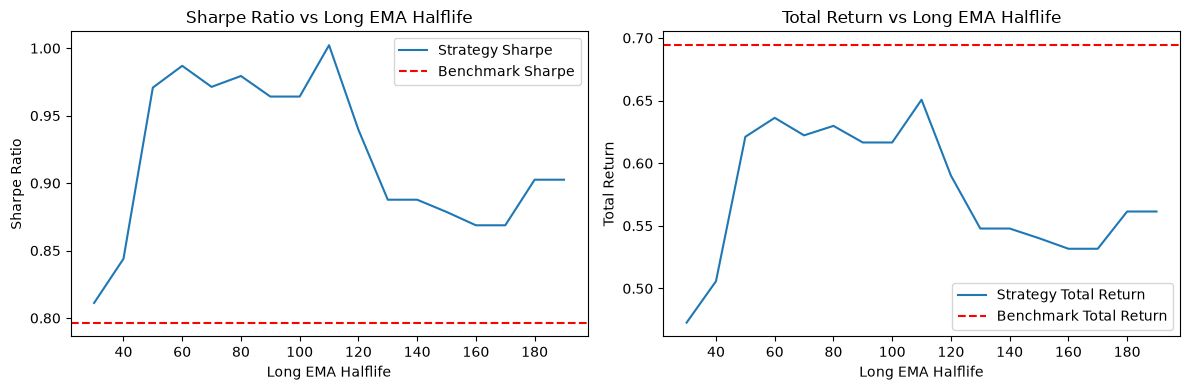

In [7]:
short_ema = ema.get_ema_series(aapl_df, period=200, halflife=20)
long_halflife_values = np.arange(30, 200, 10)
sharpe_list = np.empty(shape=len(long_halflife_values), dtype=np.float32)
total_return_list = np.empty(shape=len(long_halflife_values), dtype=np.float32)

for i, long_halflife in enumerate(long_halflife_values):
    long_ema = ema.get_ema_series(aapl_df, period=200, halflife=long_halflife)
    positions = ema_crossover.get_ema_crossover_positions(short_ema, long_ema, long_only=True)
    metrics, _, _ = backtest.compute_metrics_and_returns_from_positions_and_prices(positions, aapl_df)
    sharpe_list[i] = metrics["strategy_sharpe"]
    total_return_list[i] = metrics["strategy_total_return"]

benchmark_total_return = metrics["benchmark_total_return"]
benchmark_sharpe = metrics["benchmark_sharpe"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(long_halflife_values, sharpe_list, label='Strategy Sharpe')
axes[0].axhline(y=benchmark_sharpe, color='r', linestyle='--', label='Benchmark Sharpe')
axes[0].set_title("Sharpe Ratio vs Long EMA Halflife")
axes[0].legend()
axes[0].set_xlabel("Long EMA Halflife")
axes[0].set_ylabel("Sharpe Ratio")
axes[1].plot(long_halflife_values, total_return_list, label='Strategy Total Return')
axes[1].axhline(y=benchmark_total_return, color='r', linestyle='--', label='Benchmark Total Return')
axes[1].set_title("Total Return vs Long EMA Halflife")
axes[1].set_xlabel("Long EMA Halflife")
axes[1].set_ylabel("Total Return")
axes[1].legend()
plt.tight_layout()
plt.show()


### Short time-scale
We sweep from a half-life of 5 business days to 90

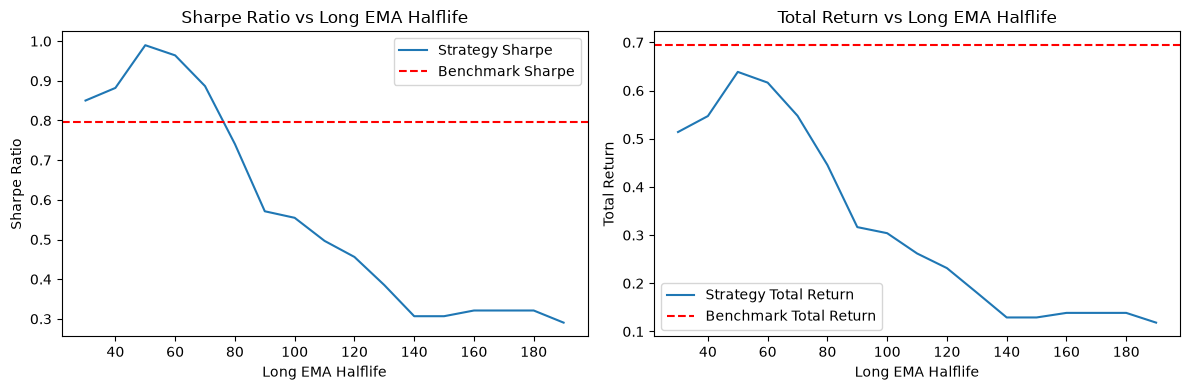

In [ ]:
long_ema = ema.get_ema_series(aapl_df, period=200, halflife=100)
short_halflife_values = np.arange(5, 90, 5)
sharpe_list = np.empty(shape=len(short_halflife_values), dtype=np.float32)
total_return_list = np.empty(shape=len(short_halflife_values), dtype=np.float32)

for i, short_halflife in enumerate(short_halflife_values):
    short_ema = ema.get_ema_series(aapl_df, period=200, halflife=short_halflife)
    positions = ema_crossover.get_ema_crossover_positions(short_ema, long_ema, long_only=True)
    metrics, _, _ = backtest.compute_metrics_and_returns_from_positions_and_prices(positions, aapl_df)
    sharpe_list[i] = metrics["strategy_sharpe"]
    total_return_list[i] = metrics["strategy_total_return"]

benchmark_total_return = metrics["benchmark_total_return"]
benchmark_sharpe = metrics["benchmark_sharpe"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(short_halflife_values, sharpe_list, label='Strategy Sharpe')
axes[0].axhline(y=benchmark_sharpe, color='r', linestyle='--', label='Benchmark Sharpe')
axes[0].set_title("Sharpe Ratio vs Short EMA Halflife")
axes[0].legend()
axes[0].set_xlabel("Short EMA Halflife")
axes[0].set_ylabel("Sharpe Ratio")
axes[1].plot(short_halflife_values, total_return_list, label='Strategy Total Return')
axes[1].axhline(y=benchmark_total_return, color='r', linestyle='--', label='Benchmark Total Return')
axes[1].set_title("Total Return vs Short EMA Halflife")
axes[1].set_xlabel("Short EMA Halflife")
axes[1].set_ylabel("Total Return")
axes[1].legend()
plt.tight_layout()
plt.show()
